In [3]:
from sklearn.datasets import make_blobs 
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples,silhouette_score
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np
import matplotlib.cm as cm

In [ ]:
make_blobs()

```python
X, y = make_blobs(n_samples=500, n_features=2, centers=4, cluster_std=1, center_box=(-10, 10), shuffle=True)
```

This Python code snippet uses the `make_blobs` function from scikit-learn to generate a synthetic dataset for clustering. Here's a breakdown of what each parameter does:

* **`make_blobs`**: This function creates clusters of data points that follow a Gaussian distribution. It's very useful for testing clustering algorithms.
* **`n_samples=500`**: This specifies that the generated dataset should contain 500 data points.
* **`n_features=2`**: This indicates that each data point will have 2 features (dimensions). This is great for visualization, as you can easily plot the data points on a 2D plane.
* **`centers=4`**: This sets the number of clusters to 4. The function will generate 4 distinct clusters of data points.
* **`cluster_std=1`**: This controls the standard deviation of the clusters. A smaller value (like 1) results in tighter, more compact clusters. A larger value would make the clusters more spread out.
* **`center_box=(-10, 10)`**: This defines the range within which the cluster centers will be randomly generated. In this case, the centers will be placed within a square box with corners at (-10, -10) and (10, 10).
* **`shuffle=True`**: This shuffles the order of the generated data points, ensuring that they are not ordered by cluster.
* **`X, y = ...`**: The function returns two values:
    * **`X`**: A NumPy array containing the generated data points. Each row of `X` represents a data point, and each column represents a feature.
    * **`y`**: A NumPy array containing the cluster labels (the true cluster assignments) for each data point. This is useful for evaluating clustering performance if you want to compare the clustering results to the "ground truth."

**In summary, this code creates a dataset with 500 data points, 2 features, 4 well-defined clusters, and shuffles the data. This type of dataset is frequently used to test and visualize clustering algorithms like K-means.**


In [4]:
X,y=make_blobs(n_samples=500,n_features=2,centers=4,cluster_std=1,center_box=(-10,10),shuffle=True)

In [5]:
X

array([[ 6.11817527e+00, -8.46273655e+00],
       [ 7.56984077e+00,  5.14498055e+00],
       [ 6.97108729e+00,  6.15533988e+00],
       [ 8.28355491e+00,  5.28594175e+00],
       [ 4.79331278e-01, -5.66825781e+00],
       [ 5.91528946e+00, -9.48862996e+00],
       [ 5.09595709e+00, -8.25865098e+00],
       [ 6.50198739e+00, -7.76531257e+00],
       [-2.71876139e+00,  2.83877092e+00],
       [-3.51822710e+00,  2.49927985e+00],
       [ 5.74970341e+00, -7.14996608e+00],
       [-3.25387248e+00,  1.45555830e+00],
       [ 7.03001631e+00, -7.32622898e+00],
       [ 6.06778837e+00, -8.46469974e+00],
       [ 5.78751954e+00,  5.93646905e+00],
       [-1.79595175e+00, -6.90461817e+00],
       [ 5.65318181e+00, -8.02883632e+00],
       [ 6.00432278e+00, -7.82671549e+00],
       [-1.82283716e+00, -5.36368587e+00],
       [-2.66683179e+00,  2.51937427e+00],
       [ 6.66640554e+00, -7.95485841e+00],
       [-1.31638508e+00,  1.74533196e+00],
       [ 7.61199725e+00, -9.30697923e+00],
       [ 4.

In [6]:
y

array([0, 3, 3, 3, 2, 0, 0, 0, 1, 1, 0, 1, 0, 0, 3, 2, 0, 0, 2, 1, 0, 1,
       0, 3, 0, 0, 1, 0, 3, 1, 3, 2, 3, 0, 3, 2, 0, 3, 0, 0, 2, 1, 1, 1,
       1, 3, 2, 3, 1, 3, 1, 0, 1, 2, 1, 1, 1, 3, 0, 1, 0, 0, 2, 1, 3, 0,
       3, 3, 2, 3, 1, 1, 1, 3, 0, 0, 1, 2, 0, 0, 0, 2, 2, 1, 1, 0, 0, 0,
       1, 3, 3, 3, 2, 3, 3, 1, 0, 2, 2, 2, 0, 0, 1, 3, 2, 2, 2, 0, 2, 0,
       1, 1, 0, 3, 2, 2, 3, 0, 0, 3, 3, 1, 2, 3, 1, 0, 3, 1, 2, 0, 2, 0,
       3, 3, 2, 3, 1, 0, 2, 3, 2, 3, 2, 3, 0, 0, 2, 3, 3, 3, 3, 3, 2, 0,
       1, 2, 2, 1, 0, 2, 0, 0, 0, 2, 1, 2, 1, 3, 2, 1, 2, 1, 3, 1, 3, 2,
       1, 3, 2, 1, 1, 1, 3, 1, 1, 2, 3, 1, 0, 1, 1, 3, 0, 3, 1, 2, 2, 0,
       1, 2, 2, 1, 0, 2, 1, 2, 3, 0, 2, 2, 1, 0, 1, 1, 0, 1, 1, 3, 1, 2,
       0, 2, 0, 2, 1, 0, 2, 1, 1, 3, 2, 0, 1, 0, 0, 2, 1, 0, 0, 3, 0, 1,
       2, 0, 2, 1, 1, 3, 0, 1, 3, 1, 1, 0, 3, 1, 0, 0, 2, 3, 3, 3, 1, 3,
       0, 3, 3, 1, 1, 3, 3, 2, 1, 3, 0, 0, 1, 1, 3, 2, 0, 0, 2, 2, 2, 0,
       2, 0, 3, 3, 2, 2, 0, 3, 0, 0, 1, 2, 1, 3, 3,

In [8]:
from sklearn.cluster import KMeans

This Python code snippet demonstrates how to calculate the Within-Cluster Sum of Squares (WCSS) for different numbers of clusters in the K-means clustering algorithm. Let's break it down:

* **`for i in range(1, 11):`**: This loop iterates through cluster counts from 1 to 10 (inclusive). This allows you to test WCSS values for a range of possible cluster numbers.
* **`kmeans = KMeans(n_clusters=i, init='k-means++')`**:
    * This line creates a `KMeans` object from the scikit-learn library.
    * `n_clusters=i`: This sets the number of clusters for the current iteration of the loop to the value of `i`.
    * `init='k-means++'`: This specifies the initialization method for the centroids. 'k-means++' is a smart initialization technique that helps to avoid poor convergence and find better clustering results compared to random initialization.
* **`kmeans.fit(X)`**: This line trains the K-means model on the data `X`. `X` is assumed to be your dataset, where each row represents a data point, and each column represents a feature.
* **`wcss.append(kmeans.inertia_)`**:
    * `kmeans.inertia_` is an attribute of the fitted `KMeans` object that stores the WCSS value for the clustering result.
    * `wcss.append(...)` adds this WCSS value to a list named `wcss`. This list will eventually contain the WCSS values for each cluster count from 1 to 10.

**In essence, this code calculates the WCSS for each number of clusters from 1 to 10 and stores these values in the `wcss` list. This is a crucial step in the "elbow method" for determining the optimal number of clusters.**

**How the Elbow Method Uses This:**

After running this code, you would typically plot the `wcss` values against the number of clusters. The resulting plot often resembles an arm, and the "elbow" point (the point where the rate of decrease in WCSS sharply changes) is considered a good estimate for the optimal number of clusters.


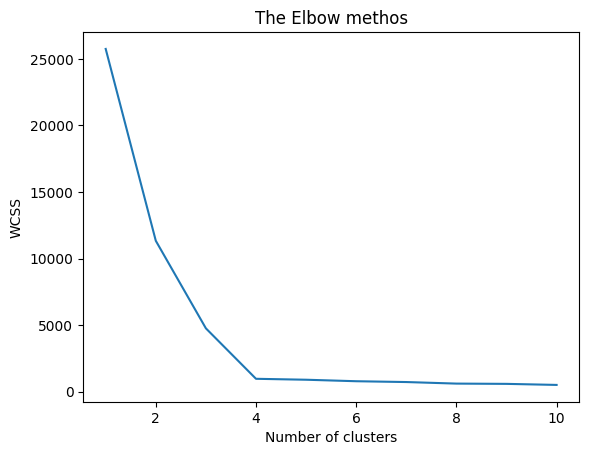

In [9]:
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i,init='k-means++')
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)


plt.plot(range(1,11),wcss)
plt.title('The Elbow methos')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

`KMeans(n_clusters=4, init='k-means++')`

This Python code creates an instance of the K-means clustering algorithm from scikit-learn. Let's break down the parameters:

* **`KMeans(...)`**: This is the constructor for the KMeans class, which initializes a K-means clustering model.
* **`n_clusters=4`**: This is the most crucial parameter. It tells the algorithm to attempt to partition the data into 4 distinct clusters. The algorithm will try to find 4 cluster centroids and assign each data point to the nearest centroid.
* **`init='k-means++'`**:
    * This parameter specifies the method used to initialize the cluster centroids.
    * 'k-means++' is a clever initialization technique that significantly improves the performance and stability of the K-means algorithm.
    * Instead of randomly selecting initial centroids, 'k-means++' strategically chooses initial centroids that are far apart from each other. This helps to avoid poor clustering results that can occur with random initialization.

**In essence, this line of code sets up a K-means model ready to be trained on data. The model is configured to find 4 clusters, and it will use the 'k-means++' initialization method to improve the quality of the clustering.**


This line of Python code is commonly used in machine learning, specifically in clustering algorithms. Let's break it down:

* `cluster_model`: This represents a trained clustering model. Examples include K-Means, DBSCAN, or hierarchical clustering.
* `fit_predict(X)`: This is a method called on the `cluster_model` object.
    * `fit()`: This part of the method trains the clustering model using the data provided in `X`. The model learns the underlying structure of the data, such as identifying clusters and their centroids (in the case of K-Means).
    * `predict()`: After the model is trained, this part assigns each data point in `X` to a cluster.
    * `X`: This is the input data, typically a NumPy array or a Pandas DataFrame. It contains the features of the data points that you want to cluster.
* `cluster_labels`: This variable stores the output of `fit_predict(X)`. It's usually a NumPy array where each element corresponds to a data point in `X`, and the value of each element represents the cluster label assigned to that data point.

In essence, this line of code performs the following steps:

1.  Trains a clustering model using the input data `X`.
2.  Assigns each data point in `X` to a cluster based on the trained model.
3.  Stores the cluster assignments (labels) in the `cluster_labels` variable.

Therefore, after executing this line, `cluster_labels` will contain an array of integers, where each integer indicates the cluster to which the corresponding data point belongs.


In [13]:
cluster_model = KMeans(n_clusters=4,init='k-means++')
cluster_labels=cluster_model.fit_predict(X)
print(cluster_labels)

[3 1 1 1 0 3 3 3 2 2 3 2 3 3 1 0 3 3 0 2 3 2 3 1 3 3 2 3 1 2 1 0 1 3 1 0 3
 1 3 3 0 2 2 2 2 1 0 1 2 1 2 3 2 0 2 2 2 1 3 2 3 3 0 2 1 3 1 1 0 1 2 2 2 1
 3 3 2 0 3 3 3 0 0 2 2 3 3 3 2 1 1 1 0 1 1 2 3 0 0 0 3 3 2 1 0 0 0 3 0 3 2
 2 3 1 0 0 1 3 3 1 1 2 0 1 2 3 1 2 0 3 0 3 1 1 0 1 2 3 0 1 0 1 0 1 3 3 0 1
 1 1 1 1 0 3 2 0 0 2 3 0 3 3 3 0 2 0 2 1 0 2 0 2 1 2 1 0 2 1 0 2 2 2 1 2 2
 0 1 2 3 2 2 1 3 1 2 0 0 3 2 0 0 2 3 0 2 0 1 3 0 0 2 3 2 2 3 2 2 1 2 0 3 0
 3 0 2 3 0 2 2 1 0 3 2 3 3 0 2 3 3 1 3 2 0 3 0 2 2 1 3 2 1 2 2 3 1 2 3 3 0
 1 1 1 2 1 3 1 1 2 2 1 1 0 2 1 3 3 2 2 1 0 3 3 0 0 0 3 0 3 1 1 0 0 3 1 3 3
 2 0 2 1 1 1 3 1 0 0 1 2 1 2 0 0 3 3 2 0 1 0 0 3 2 3 2 1 1 2 1 3 1 0 1 0 3
 0 1 3 2 1 3 3 1 3 2 1 0 0 2 1 2 1 0 0 2 1 1 3 2 2 2 3 1 1 0 2 1 0 3 0 0 2
 1 2 0 1 0 2 3 0 3 2 0 3 0 1 1 2 1 3 0 1 3 3 0 1 1 0 0 0 3 0 0 1 2 0 3 2 2
 1 2 3 1 3 1 0 1 3 3 0 0 0 3 1 3 1 2 0 0 2 2 0 0 3 0 1 2 1 0 0 2 3 2 0 0 0
 1 0 2 2 1 0 1 2 3 2 3 0 3 2 3 1 2 3 1 0 3 1 2 2 0 3 1 1 2 3 2 0 2 3 3 3 0
 3 2 0 0 1 0 2 3 0 1 1 1 

In [18]:
silhouette_avg = silhouette_score(X, cluster_labels)
print(silhouette_avg)

0.5334094996500602


In [19]:
sample_silhouette_values = silhouette_samples(X, cluster_labels)

print(sample_silhouette_values)

[ 0.14479746  0.86314465  0.8651599   0.8473346   0.66805805  0.1052578
  0.40033805  0.27022063  0.55052284  0.40499093  0.25373554  0.20757516
  0.31850085  0.10677693  0.79130288  0.73584484  0.26362864  0.05941189
  0.7758081   0.4968005   0.36402554  0.19734204  0.41285297  0.49426328
  0.44935373  0.19429041  0.41654003  0.07969048  0.77819338  0.10619578
  0.85056782  0.76944377  0.86599464  0.29026741  0.86670684  0.67977837
  0.39645138  0.8699296   0.26075151  0.32957284  0.77591471  0.42628282
  0.07859552  0.48960195  0.39046864  0.79307988  0.3138699   0.83796026
  0.50797347  0.66862112  0.26750211  0.19519299  0.10052921  0.79943691
  0.1506418   0.26981553  0.18960922  0.87420795  0.12142653  0.55668832
  0.1171108   0.11152763  0.52808825  0.33959383  0.70610892  0.42434038
  0.82512782  0.84668584  0.80361404  0.78527648  0.36400076  0.31383016
  0.30771061  0.82718975  0.45313665  0.40159676  0.36804276  0.68478269
  0.33921485  0.44515166  0.16043988  0.72639712  0.

In [21]:
lst_sl_avg=[]
for i in range(2,6):
    cluster_model=KMeans(n_clusters=i,init='k-means++')
    cluster_label=cluster_model.fit_predict(X)
    sil_avg = silhouette_score(X,cluster_labels)
    lst_sl_avg.append(sil_avg)

In [22]:
lst_sl_avg

[np.float64(0.5334094996500602),
 np.float64(0.5334094996500602),
 np.float64(0.5334094996500602),
 np.float64(0.5334094996500602)]

For n_clusters = 2 The average silhouette_score is : 0.5476941537995933
For n_clusters = 3 The average silhouette_score is : 0.6671289145416508
For n_clusters = 4 The average silhouette_score is : 0.779073795086083
For n_clusters = 5 The average silhouette_score is : 0.6440289278637933
For n_clusters = 6 The average silhouette_score is : 0.5334094996500602


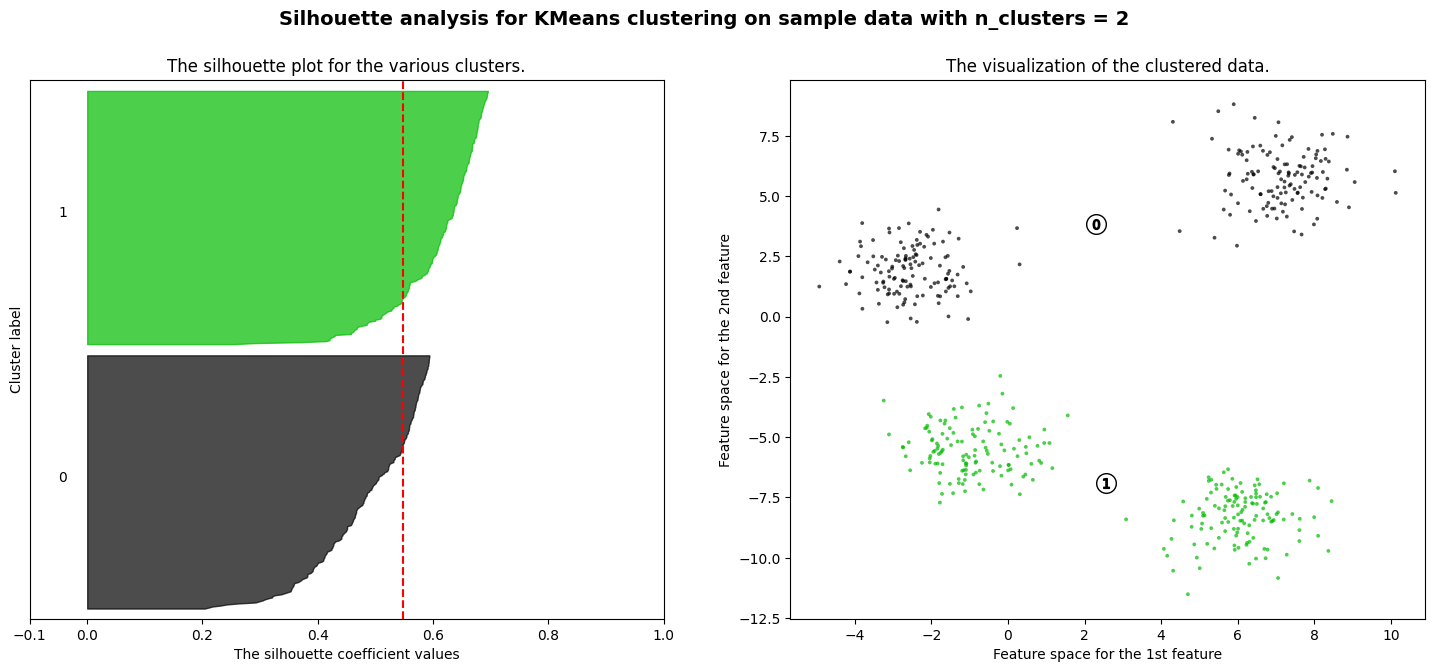

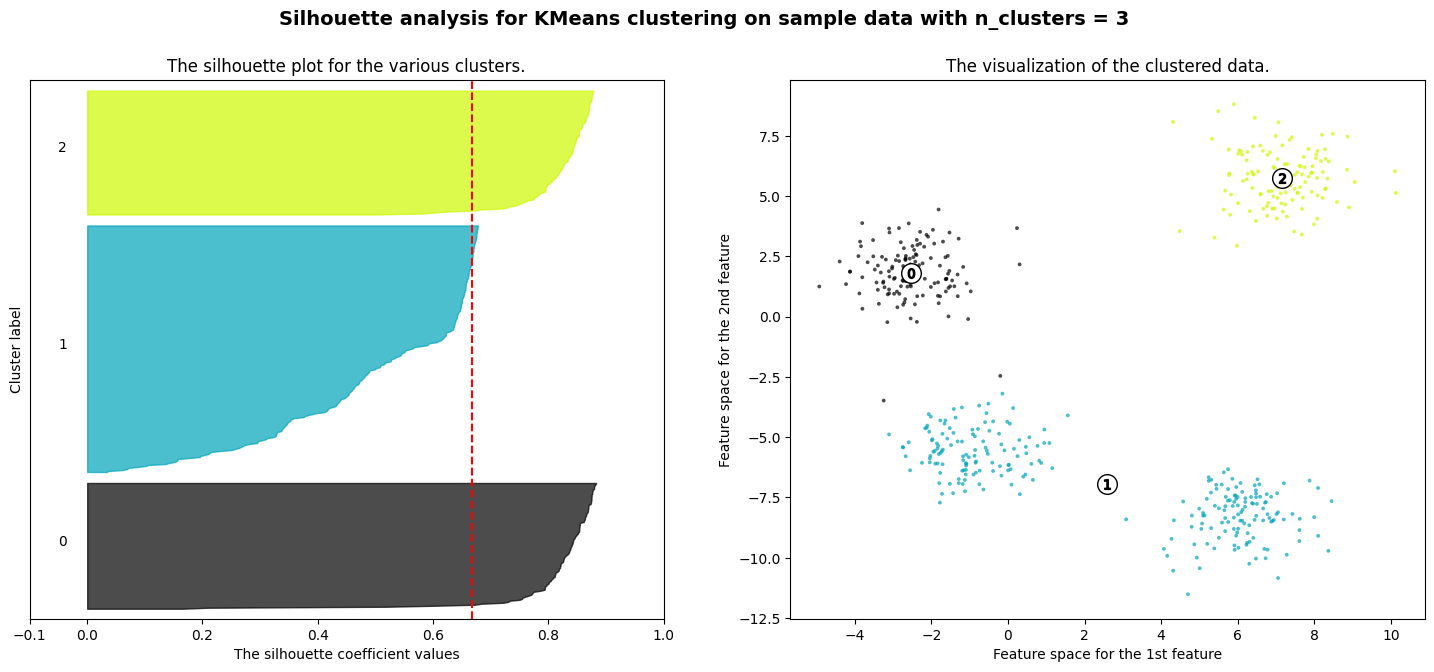

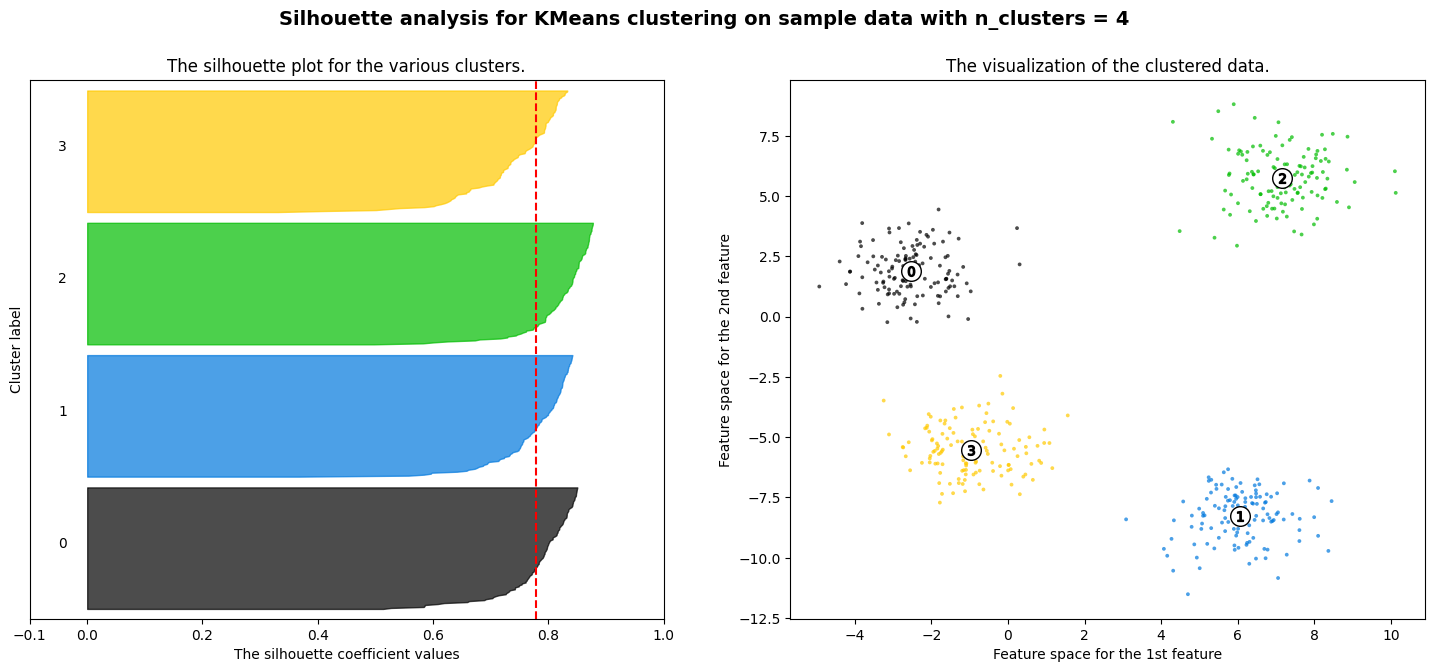

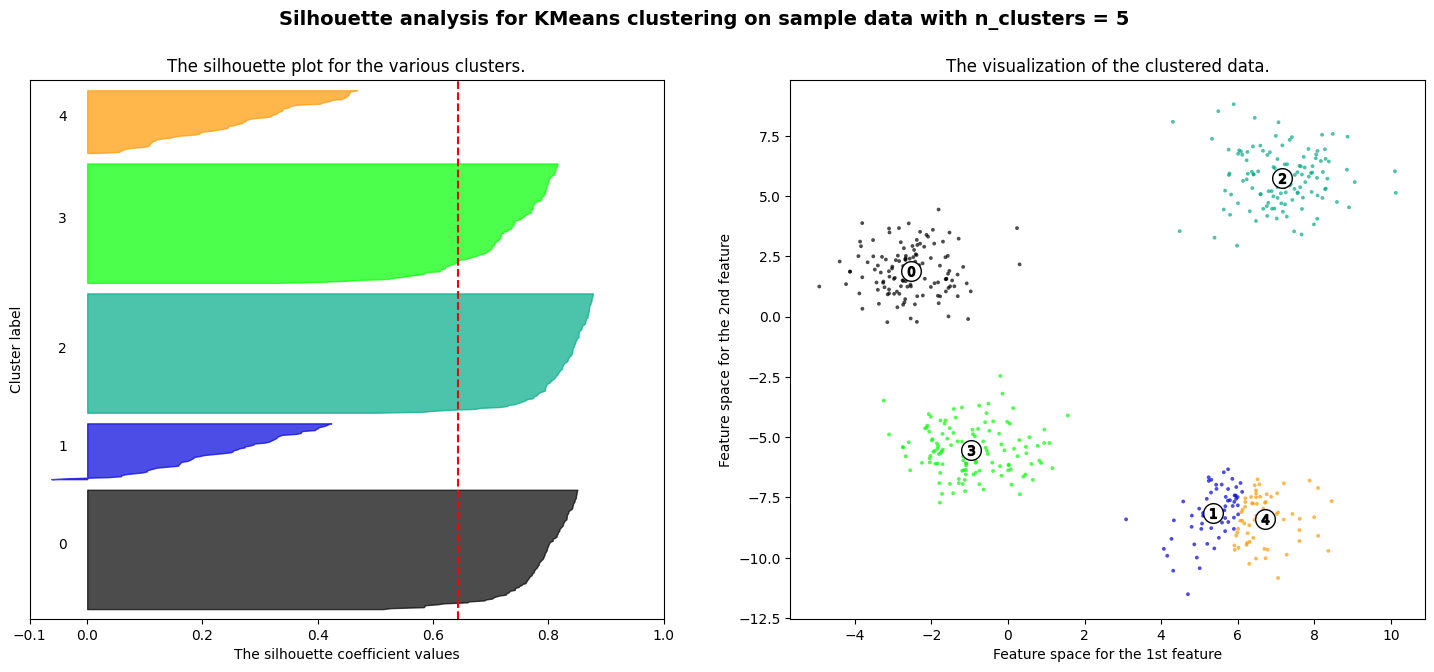

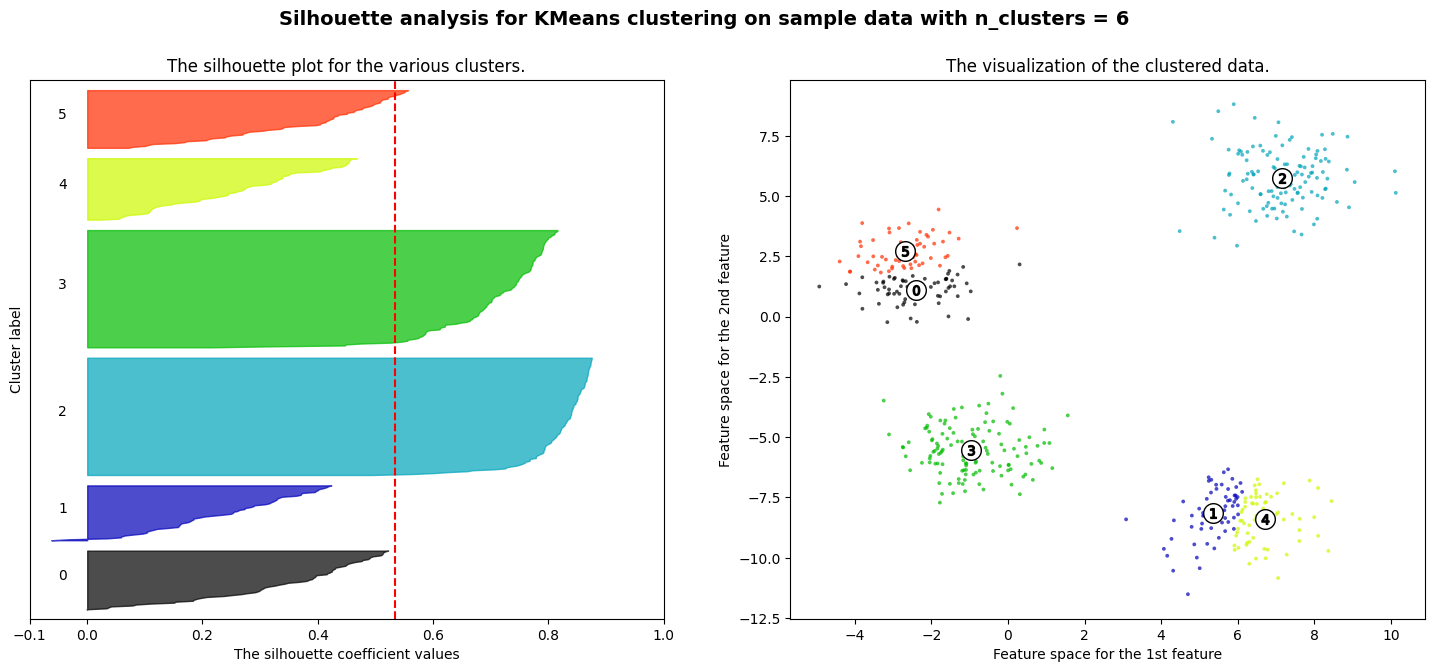

In [16]:
range_n_clusters=[2,3,4,5,6]
for n_clusters in range_n_clusters:
    # Create a subplot with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    # The 1st subplot is the silhouette plot
    # The silhouette coefficient can range from -1, 1 but in this example all
    # lie within [-0.1, 1]
    ax1.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters value and a random generator
    # seed of 10 for reproducibility.
    clusterer = KMeans(n_clusters=n_clusters, random_state=10)
    cluster_labels = clusterer.fit_predict(X)

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg = silhouette_score(X, cluster_labels)
    print("For n_clusters =", n_clusters,
          "The average silhouette_score is :", silhouette_avg)

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(X, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = \
            sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # 2nd Plot showing the actual clusters formed
    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(X[:, 0], X[:, 1], marker='.', s=30, lw=0, alpha=0.7,
                c=colors, edgecolor='k')

    # Labeling the clusters
    centers = clusterer.cluster_centers_
    # Draw white circles at cluster centers
    ax2.scatter(centers[:, 0], centers[:, 1], marker='o',
                c="white", alpha=1, s=200, edgecolor='k')

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker='$%d$' % i, alpha=1,
                    s=50, edgecolor='k')

    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")

    plt.suptitle(("Silhouette analysis for KMeans clustering on sample data "
                  "with n_clusters = %d" % n_clusters),
                 fontsize=14, fontweight='bold')

plt.show()